# Trustworthy AI: Week 4 Lab
## Explainable AI for Loan Approval

This notebook works through all nine lab steps as a mix of markdown and code cells:
- **Steps 1-6** (code + markdown): load and explore the loan dataset, train a baseline classifier, then generate and compare LIME and SHAP explanations.
- **Steps 7-9** (markdown only, no code required): counterfactual explanation, stakeholder analysis, and final reflection — to be expanded on in the accompanying PPT.

The full notebook is intended to be presented as a PPT deck; individual reflections from each team member are to be included in the PPT.

## Step 1: Load Loan Dataset

We start by loading `loan_data.csv` and performing basic exploratory data analysis (EDA):
- Inspect the features (data types, categorical vs numeric)
- Identify the target variable
- Check the class distribution of the target
- Check for missing values, since these will need to be handled before modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('loan_data.csv')

print('Shape:', df.shape)
df.head()

Shape: (381, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    str    
 1   Gender             376 non-null    str    
 2   Married            381 non-null    str    
 3   Dependents         373 non-null    str    
 4   Education          381 non-null    str    
 5   Self_Employed      360 non-null    str    
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    str    
 12  Loan_Status        381 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 38.8 KB


Loan_Status
Y    271
N    110
Name: count, dtype: int64
Loan_Status
Y    0.711286
N    0.288714
Name: proportion, dtype: float64


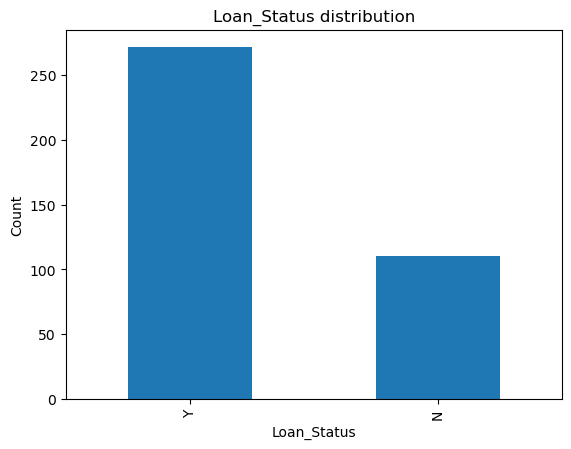

In [3]:
# Target variable distribution
print(df['Loan_Status'].value_counts())
print(df['Loan_Status'].value_counts(normalize=True))

df['Loan_Status'].value_counts().plot(kind='bar', title='Loan_Status distribution')
plt.xlabel('Loan_Status')
plt.ylabel('Count')
plt.show()

In [4]:
# Missing values per column
df.isnull().sum().sort_values(ascending=False)

Credit_History       30
Self_Employed        21
Loan_Amount_Term     11
Dependents            8
Gender                5
Education             0
Married               0
Loan_ID               0
ApplicantIncome       0
LoanAmount            0
CoapplicantIncome     0
Property_Area         0
Loan_Status           0
dtype: int64

### Observations

**Features:**
- `Loan_ID` is an identifier with no predictive value and will be dropped before modeling.
- Categorical features: `Gender`, `Married`, `Dependents`, `Education`, `Self_Employed`, `Property_Area`.
- Numeric features: `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term`, `Credit_History`.

**Target variable:** `Loan_Status` (`Y` = approved, `N` = rejected).

**Class distribution:** Of 381 applicants, 271 (71.1%) were approved (`Y`) and 110 (28.9%) were rejected (`N`). This is a **moderate class imbalance** — accuracy alone may be misleading, so precision/recall (especially for the minority `N` class) should also be reported in Step 2.

**Missing data:** Five columns have missing values: `Credit_History` (30), `Self_Employed` (21), `Loan_Amount_Term` (11), `Dependents` (8), and `Gender` (5). `Credit_History` is notable since it is typically one of the strongest predictors of loan approval — we will impute it (most-frequent) rather than drop rows, to avoid losing too much data.

## Step 2: Build Baseline Model

We now build a baseline **Random Forest** classifier:
- Drop `Loan_ID` (no predictive value)
- Split into train/test sets first (stratified, given the 71/29 class imbalance from Step 1), so that all preprocessing below is *fit on the training set only* and the test set remains unseen
- Impute missing values identified in Step 1 (median for numeric, most-frequent for categorical), fit on the training set and applied to both
- Ordinal-encode categorical features (fit on the training set; kept as integer-encoded columns rather than one-hot, so LIME/SHAP can work directly with a simple numeric feature matrix in Steps 3-5)
- Use `class_weight='balanced'` in the Random Forest to directly address the 71/29 class imbalance from Step 1, by up-weighting the minority `N` (rejected) class during training
- Train the Random Forest, evaluate accuracy/precision/recall, and generate predictions for the test set

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

df_model = df.drop(columns=['Loan_ID']).copy()

categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
feature_cols = categorical_cols + numeric_cols

target_encoder = LabelEncoder()
df_model['Loan_Status'] = target_encoder.fit_transform(df_model['Loan_Status'])  # N=0, Y=1

X = df_model[feature_cols]
y = df_model['Loan_Status']

# Split before fitting any imputer/encoder, so the test set stays completely unseen during preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X_train.copy(), X_test.copy()

# Impute missing values (medians/modes learned from the training set only)
num_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

# Ordinal-encode categorical features (fit on train, applied to test)
cat_encoder = OrdinalEncoder()
X_train[categorical_cols] = cat_encoder.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_encoder.transform(X_test[categorical_cols])

# Human-readable category names per encoded categorical feature, indexed by encoded value
# (used by LIME in Step 3 so its explanations show e.g. "Married=Yes" instead of "Married=1.00")
categorical_names = {
    feature_cols.index(col): list(cats)
    for col, cats in zip(categorical_cols, cat_encoder.categories_)
}

X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
183,1.0,1.0,2.0,0.0,0.0,1.0,4400.0,0.0,127.0,360.0,0.0
306,1.0,1.0,0.0,0.0,0.0,1.0,2083.0,3150.0,128.0,360.0,1.0
6,1.0,1.0,2.0,0.0,0.0,2.0,2500.0,1840.0,109.0,360.0,1.0
270,1.0,1.0,0.0,0.0,0.0,0.0,2666.0,4300.0,121.0,360.0,1.0
368,1.0,1.0,0.0,0.0,0.0,2.0,2297.0,1522.0,104.0,360.0,1.0


In [6]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

Accuracy: 0.8441558441558441

              precision    recall  f1-score   support

           N       0.81      0.59      0.68        22
           Y       0.85      0.95      0.90        55

    accuracy                           0.84        77
   macro avg       0.83      0.77      0.79        77
weighted avg       0.84      0.84      0.84        77



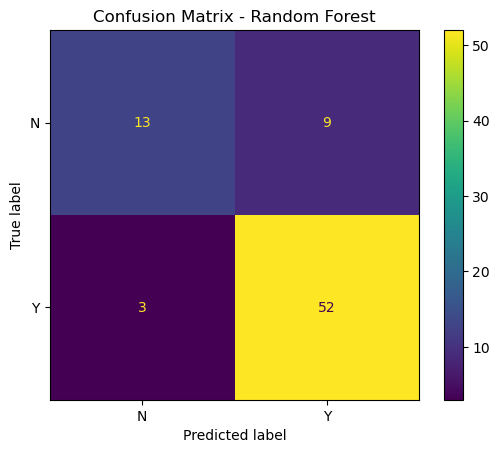

In [7]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

y_pred = rf_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_encoder.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [8]:
# Generate predictions on the test set for use in Step 3 (selecting an applicant for LIME)
results = X_test.copy()
results['Actual'] = target_encoder.inverse_transform(y_test)
results['Predicted'] = target_encoder.inverse_transform(y_pred)
results.reset_index(inplace=True)
results.rename(columns={'index': 'test_index'}, inplace=True)
results.head(10)

,test_index,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Actual,Predicted
0,244,1.0,1.0,0.0,0.0,0.0,2.0,2333.0,2417.0,136.0,360.0,1.0,Y,Y
1,380,0.0,0.0,0.0,0.0,1.0,1.0,4583.0,0.0,133.0,360.0,0.0,N,N
2,239,1.0,1.0,0.0,0.0,0.0,1.0,3333.0,2500.0,128.0,360.0,1.0,Y,Y
3,90,0.0,1.0,0.0,0.0,0.0,1.0,2330.0,4486.0,100.0,360.0,1.0,Y,Y
4,55,1.0,1.0,1.0,0.0,1.0,2.0,1000.0,3022.0,110.0,360.0,1.0,N,Y
5,276,1.0,0.0,0.0,0.0,0.0,0.0,6500.0,0.0,105.0,360.0,0.0,N,N
6,365,0.0,1.0,0.0,0.0,0.0,1.0,3166.0,0.0,36.0,360.0,1.0,Y,Y
7,41,1.0,1.0,2.0,0.0,0.0,1.0,2708.0,1167.0,97.0,360.0,1.0,Y,Y
8,11,0.0,0.0,0.0,0.0,0.0,2.0,3510.0,0.0,76.0,360.0,0.0,N,N
9,124,0.0,0.0,0.0,0.0,0.0,2.0,3244.0,0.0,80.0,360.0,1.0,Y,Y


### Observations

**Overall accuracy: 84.4%** on the held-out test set (77 applicants).

**Per-class performance:**
- **Class Y (approved)**: precision 0.85, recall 0.95, f1 0.90
- **Class N (rejected)**: precision 0.81, recall 0.59, f1 0.68
- **Macro-F1: 0.79**

**Interpretation:** `class_weight='balanced'` was applied to counter the 71/29 imbalance flagged in Step 1, by up-weighting the minority `N` (rejected) class during training. Even so, a clear recall gap remains between the two classes: the model correctly identifies 95% of approved (`Y`) applicants but only 59% of rejected (`N`) applicants. This gap is an important trustworthiness finding — it means the model is still considerably more likely to mistakenly *approve* a rejected applicant (a false `Y`) than to mistakenly *reject* an approved applicant (a false `N`), which is the more costly error type for a loan-rejection use case. We proceed with this model for the rest of the notebook.

**Predictions table:** The `results` DataFrame above pairs each test-set applicant's feature values with their actual and predicted `Loan_Status`. We will select one applicant from here in Step 3 for the LIME explanation — ideally a case where the model's reasoning is interesting (e.g., a predicted rejection, or a borderline case).

## Step 3: Generate LIME Explanation

LIME (Local Interpretable Model-agnostic Explanations) explains a single prediction by fitting a simple, interpretable model around that one data point.

We select test applicant `test_index=55` — this is a **false positive** (Actual = `N`, Predicted = `Y`), i.e. a case the model approved but should have rejected. This makes it a good candidate to inspect:
- Build a `LimeTabularExplainer` using the training data, marking the ordinal-encoded categorical columns (with their category names) so LIME treats them correctly and reports human-readable category labels
- Generate a local explanation for this applicant's prediction
- Identify which features pushed the prediction toward `Y` (approve) vs `N` (reject)

Actual:    N
Predicted: Y


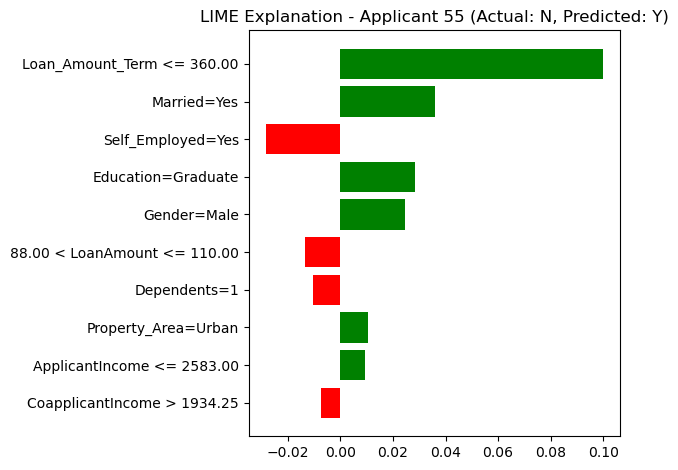

In [9]:
import lime
import lime.lime_tabular

categorical_feature_indices = [feature_cols.index(c) for c in categorical_cols]

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=feature_cols,
    class_names=target_encoder.classes_,
    categorical_features=categorical_feature_indices,
    categorical_names=categorical_names,
    discretize_continuous=True,
    random_state=42
)

# Wrapper so LIME's internal calls pass a properly-named DataFrame to the model
def predict_proba_fn(x):
    return rf_model.predict_proba(pd.DataFrame(x, columns=feature_cols))

applicant_idx = 55
applicant = X_test.loc[applicant_idx]

actual_label = target_encoder.inverse_transform([y_test.loc[applicant_idx]])[0]
predicted_label = target_encoder.inverse_transform(rf_model.predict(applicant.to_frame().T))[0]
print('Actual:   ', actual_label)
print('Predicted:', predicted_label)

lime_exp = explainer.explain_instance(applicant.values, predict_proba_fn, num_features=10)
fig = lime_exp.as_pyplot_figure()
plt.title(f'LIME Explanation - Applicant {applicant_idx} (Actual: {actual_label}, Predicted: {predicted_label})')
plt.tight_layout()
plt.show()

In [10]:
# Textual list of feature contributions (in case the HTML widget above doesn't render)
for feature, weight in lime_exp.as_list():
    print(f'{feature:30s} {weight:+.4f}')

Loan_Amount_Term <= 360.00     +0.1000
Married=Yes                    +0.0360
Self_Employed=Yes              -0.0284
Education=Graduate             +0.0283
Gender=Male                    +0.0247
88.00 < LoanAmount <= 110.00   -0.0136
Dependents=1                   -0.0104
Property_Area=Urban            +0.0104
ApplicantIncome <= 2583.00     +0.0093
CoapplicantIncome > 1934.25    -0.0074


### Observations

For applicant 55 (Actual = `N`, Predicted = `Y`), the strongest factors pushing the model toward **approval (`Y`)** were:
- `Loan_Amount_Term <= 360.00` (+0.100) — by far the largest contributor
- `Married = Yes` (+0.036)
- `Education = Graduate` (+0.028)
- `Gender = Male` (+0.025)
- `Property_Area = Urban` (+0.010)
- `ApplicantIncome <= 2583.00` (+0.009)

The factors pushing toward **rejection (`N`)** — i.e. the ones that were "right" but got outweighed — were:
- `Self_Employed = Yes` (-0.028) — the largest negative contributor
- `LoanAmount` between 88-110 (-0.014)
- `Dependents = 1` (-0.010)
- `CoapplicantIncome > 1934.25` (-0.007)

**Interpretation:** The combination of a standard 360-month loan term plus demographic/profile factors (married, graduate, male, urban) is enough to outweigh the negative signals (self-employed, a mid-range loan amount, high co-applicant income, more dependents). None of these top-10 features individually look like an obvious red flag, consistent with this being a genuinely borderline case.

**A counterintuitive finding:** despite this applicant having a relatively low `ApplicantIncome` (1000), LIME finds it to be a (small) positive contributor toward approval (+0.009). We'll see SHAP find the same direction, more strongly, in Step 4 — two independent methods agreeing on this surprising local effect is a useful trustworthiness signal, explored further in Step 6.

## Step 4: Generate SHAP Waterfall Plot

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value based on game-theoretic Shapley values, measuring how much each feature pushes the prediction away from the model's average (base) output.

We continue with the same applicant (`test_index=55`) so we can directly compare SHAP's local explanation against LIME's from Step 3:
- Build a `TreeExplainer` (efficient, exact SHAP values for tree-based models like Random Forest)
- Compute SHAP values for the test set
- Generate a waterfall plot for applicant 55, for the `Y` (approve) class — showing how each feature pushes the prediction from the base value toward the final output
- Observe which features contribute positively vs negatively

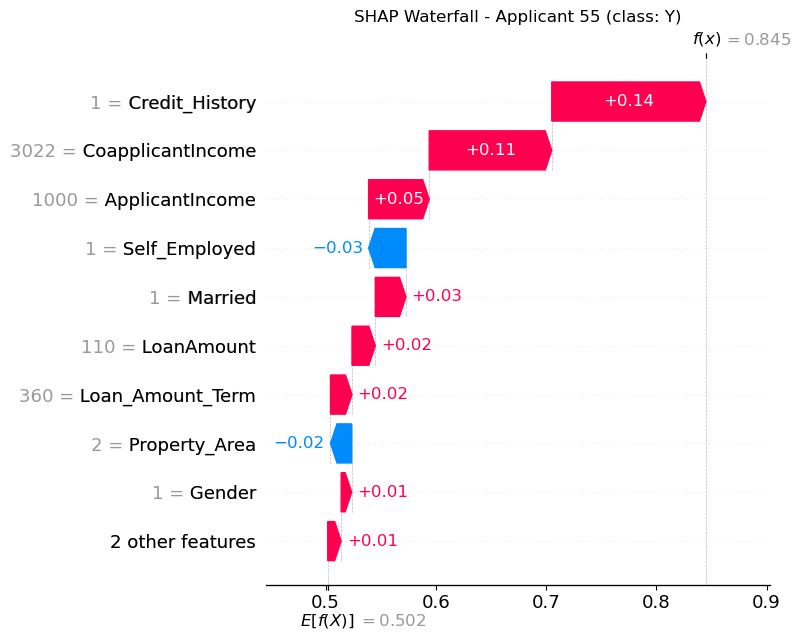

In [11]:
import shap

shap_explainer = shap.TreeExplainer(rf_model)
shap_explanation = shap_explainer(X_test)

# Position of applicant 55 within X_test (SHAP indexes by position, not by original df index)
applicant_pos = X_test.index.get_loc(applicant_idx)

# class index for 'Y' (approve)
y_class_idx = list(target_encoder.classes_).index('Y')

shap.plots.waterfall(shap_explanation[applicant_pos, :, y_class_idx], show=False)
plt.title(f'SHAP Waterfall - Applicant {applicant_idx} (class: Y)')
plt.tight_layout()
plt.show()

### Observations

The waterfall plot starts at the **base value** (≈0.50 — the model's average predicted probability of `Y` across the dataset, reflecting the `class_weight='balanced'` setting used during training) and shows each feature pushing toward the final prediction of **≈0.85** for applicant 55.

**Largest positive contributions (toward approval):**
- `Credit_History = 1.0` (+0.140) — the single largest contributor
- `CoapplicantIncome = 3022` (+0.111) — second largest
- `ApplicantIncome = 1000` (+0.055) — third largest
- `Married = 1` (+0.028)
- `LoanAmount = 110` (+0.021)
- `Loan_Amount_Term = 360` (+0.020)

**Negative contributions (toward rejection):**
- `Self_Employed = 1` (-0.034) — the largest negative contributor
- `Property_Area = 2` (-0.019)

**Interpretation:** `Credit_History` and `CoapplicantIncome` remain the dominant positive contributors, consistent with their high global importance (Step 5). A notable finding is `ApplicantIncome`: despite this applicant having a *low* income (1000), SHAP assigns it a sizeable *positive* contribution (+0.055, third-largest overall) — agreeing with LIME's small positive contribution for the same feature in Step 3. Two independent explanation methods agreeing on this surprising local effect (low income → pushes toward approval, likely because the model has learned to compensate for low `ApplicantIncome` when `CoapplicantIncome` and `Credit_History` are strong) gives us more confidence it reflects a real pattern the model learned, not noise from one method's approximation. `Loan_Amount_Term` (LIME's top feature) again contributes only modestly (+0.020) to SHAP's decomposition — we compare these two explanations more directly in Step 6.

## Step 5: Generate SHAP Summary Plot

While the waterfall plot in Step 4 explained a single prediction (local), a SHAP **summary (beeswarm) plot** aggregates SHAP values across the entire test set to show **global** feature importance — which features matter most overall, and whether their effect is generally positive or negative.

We reuse the `shap_explanation` computed in Step 4 (for the `Y`/approve class) across all test applicants.

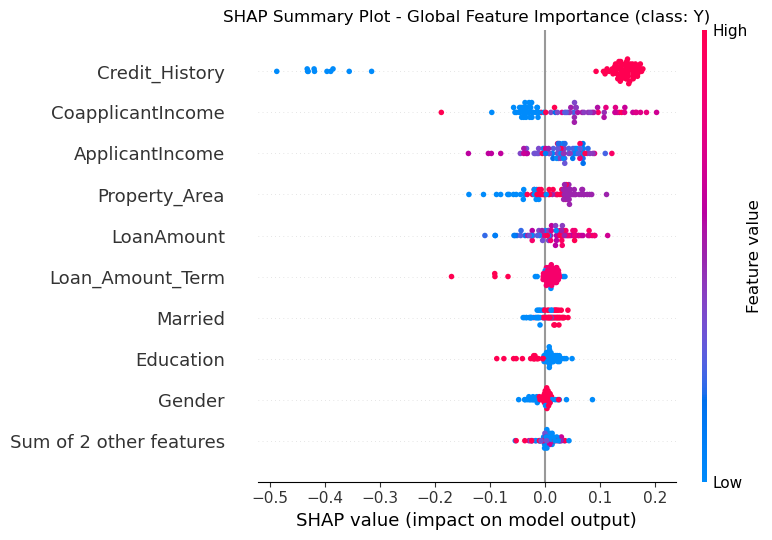

In [12]:
shap.plots.beeswarm(shap_explanation[:, :, y_class_idx], show=False)
plt.title('SHAP Summary Plot - Global Feature Importance (class: Y)')
plt.tight_layout()
plt.show()

### Observations

Ranked by mean absolute SHAP value (global importance for predicting `Y`):

1. `Credit_History` (0.183) — by far the most important feature overall, consistent with domain expectations for loan approval
2. `CoapplicantIncome` (0.065)
3. `ApplicantIncome` (0.045)
4. `Property_Area` (0.040)
5. `LoanAmount` (0.037)
6. `Loan_Amount_Term` (0.018)
7. `Married` (0.018)
8. `Education` (0.017)
9. `Gender` (0.012)
10. `Dependents` (0.011)
11. `Self_Employed` (0.006)

**Interpretation:** `Credit_History` dominates globally — its mean impact (0.183) is roughly 2.8x the next most important feature. This matches its role as the largest single contributor for applicant 55 in Step 4. The financial features (`CoapplicantIncome`, `ApplicantIncome`, `LoanAmount`) plus `Property_Area` form a clear second tier, reflecting the model's reliance on financial signals to distinguish approved from rejected applicants. Demographic features (`Gender`, `Married`, `Education`, `Dependents`, `Self_Employed`) cluster at the bottom — reassuring from a fairness standpoint, though `Married`, `Education`, and `Gender` did show up as non-trivial local contributors for applicant 55 in Step 3's LIME explanation, and `Married`/`Loan_Amount_Term` are nearly tied for 6th/7th place. The beeswarm plot also shows the *direction* of each feature's effect: points colored for high `Credit_History` cluster on the positive (right) side, confirming that having a good credit history consistently pushes predictions toward `Y`.

## Step 6: Compare LIME vs SHAP

**Ease of understanding:**
- LIME's bar chart is immediately intuitive — each feature/condition (e.g. `Loan_Amount_Term <= 360.00`) has a single signed weight, similar to a regression coefficient.
- SHAP's waterfall plot is also easy to read for a single prediction (it visually "walks" from the base rate to the final prediction), but the beeswarm summary plot has a steeper learning curve — it packs distribution, magnitude, and direction (color) into one chart.

**Detail provided:**
- LIME only explains the *local* neighborhood of one prediction using a simplified surrogate model — it doesn't tell us anything about the model's behavior elsewhere.
- SHAP provides both local (waterfall) and global (beeswarm) views from the *same* underlying values, and its values are additive (they sum exactly to the difference between the prediction and the base rate), which LIME's weights do not guarantee.

**Trustworthiness:**
- For applicant 55, LIME ranked `Loan_Amount_Term` as the top factor, while SHAP ranked `Credit_History` and `CoapplicantIncome` highest. Both attempt to explain the *same* prediction from the *same* model, yet they disagree on the leading cause. This discrepancy is important: it shows that a single explanation method can give a misleading picture of "why" a model made a decision, and that relying on only one method risks over-trusting an explanation that happens to be an artifact of that method's approximation (LIME's local linear surrogate vs SHAP's exact Shapley decomposition).
- SHAP's global consistency (Step 5 confirms `Credit_History` is the dominant feature overall, matching its dominance for applicant 55) makes it feel more trustworthy here — LIME's top feature for this applicant (`Loan_Amount_Term`) is actually one of the *least* important features globally (tied for rank 6 of 11 with `Married`), suggesting LIME's local surrogate may have overweighted a feature that happened to vary in this applicant's neighborhood in the training data.
- Interestingly, both methods *do* agree on one subtle point: LIME (Step 3, +0.009) and SHAP (Step 4, +0.055) both find `ApplicantIncome` to be a positive contributor toward approval for applicant 55, despite this applicant having a relatively low income — a surprising local effect that both methods independently surface. When two otherwise-disagreeing methods agree on a specific, non-obvious effect, that agreement is itself a useful trustworthiness signal.
- **Overall**: SHAP provides a more theoretically grounded and globally-consistent explanation, but LIME is faster to compute and easier to explain to a non-technical stakeholder for a single decision. For high-stakes decisions like loan approval, using both — and flagging cases where they disagree (and where they agree), as we did here — is a stronger trustworthiness practice than relying on either alone.

## Step 7: Counterfactual Explanation

A counterfactual explanation answers: *"What is the smallest change to this applicant's profile that would flip the model's decision?"*

**Standard counterfactual (rejected applicant → approval):** For an applicant predicted `N` (rejected), the three levers suggested in the lab scaffold would typically be:

- **Increase income** (`ApplicantIncome` and/or `CoapplicantIncome`): higher combined income improves the applicant's apparent repayment capacity, and Step 5's SHAP summary confirms `CoapplicantIncome` and `ApplicantIncome` are the 2nd and 3rd most important global features.
- **Reduce loan amount** (`LoanAmount`): a smaller request relative to income lowers perceived repayment risk — also a top-5 global feature (rank 5).
- **Improve credit history** (`Credit_History`: 0 → 1): per Step 5, this is by far the most influential feature overall (mean |SHAP| ≈ 0.183, roughly 2.8x the next feature), so this single change is the most likely to flip a rejection to an approval on its own.

**Applicant-55-specific counterfactual (the reverse direction):** Applicant 55 (Actual = `N`, Predicted = `Y`, predicted probability of `Y` ≈ 0.85) is a *false positive* — the model already approved them, but their true label was `N`. The more illustrative question for this case is therefore the reverse: **what would need to be different for this applicant to instead be predicted `N` (matching their true label)?** Based on the SHAP and LIME contributions from Steps 3-4, the most influential levers (in reverse) are:

- **Worsen `Credit_History`** (1.0 → 0.0): this was the single largest positive contributor (+0.140 SHAP). Flipping it to "no credit history" would remove the model's strongest reason to approve, and is the single most likely change to flip the prediction to `N` — mirroring how *improving* credit history is the strongest lever in the standard direction above.
- **Reduce `CoapplicantIncome`** (3022 → 0): this was the second largest positive contributor (+0.111 SHAP) — the mirror image of "increase income" above.
- **Reduce `ApplicantIncome`'s offsetting effect**: somewhat counterintuitively (see Step 4), this applicant's *low* `ApplicantIncome` (1000) is currently a *positive* contributor (+0.055) — likely because the model treats it as "compensated for" by the strong `CoapplicantIncome` and `Credit_History`. Removing that compensation (e.g. if `CoapplicantIncome` or `Credit_History` were also weaker) would let the low `ApplicantIncome` act as a normal negative signal instead.
- **Increase `LoanAmount`** relative to income: a larger requested loan amount relative to combined income would signal higher risk and is a contributor the model is sensitive to (LoanAmount appears in both LIME's and SHAP's top features) — the mirror image of "reduce loan amount" above.
- **Change `Self_Employed`** from `Yes` to `No`: this is the largest *negative* contributor (-0.034 SHAP) for this applicant; for a different applicant this could be a meaningful lever, since self-employment is associated with less stable income.

**Takeaway:** Unlike LIME/SHAP (which explain *why* a decision was made), a counterfactual explains *what would need to change* to get a different outcome — this is often the most actionable explanation for an applicant ("improve your credit history", "increase your income", or "request a smaller loan" are all things they can act on). Reassuringly, the same core features (`Credit_History`, `CoapplicantIncome`/income, `LoanAmount`) dominate the counterfactual in *both* directions, which is consistent with their dominance in the global SHAP ranking from Step 5. A counterfactual can also surface fairness concerns if the "easiest" change involves a protected attribute (e.g., `Gender` or `Married`) rather than a financial one — here, `Self_Employed` is the only non-financial feature among the top levers, and even it is a relatively minor contributor compared to `Credit_History` and `CoapplicantIncome`.

## Step 8: Stakeholder Analysis

Different stakeholders care about different aspects of the same explanation. Using applicant 55's case as a running example:

**Applicant**
- Cares about: "Why was my loan approved/rejected, and what can I do about it?"
- Most useful explanation: the **counterfactual** from Step 7 — concrete, actionable changes ("improve credit history", "reduce loan amount relative to income").
- Concern: SHAP/LIME values (e.g. "+0.140 for Credit_History") are not meaningful to a non-technical applicant without translation into plain language.

**Regulator**
- Cares about: whether the model complies with fair-lending requirements (e.g., does not discriminate on protected attributes like `Gender` or `Married` status).
- Most useful explanation: the **SHAP summary plot** (Step 5) — it shows that demographic features (`Gender`, `Married`, `Education`, `Dependents`, `Self_Employed`) have low *global* importance, which supports (but does not prove) a fairness argument. The regulator would also want to see the **per-class recall gap** from Step 2 (recall 0.95 for `Y` vs 0.59 for `N`) investigated for disparate impact across demographic groups — this gap means the model is considerably more likely to wrongly approve a rejected applicant than to wrongly reject an approved one, and that asymmetry needs to be explained, not just the headline accuracy.

**Auditor**
- Cares about: consistency and reproducibility of explanations, and whether the model's stated reasoning matches its actual behavior.
- Most useful explanation: the **comparison in Step 6** — the fact that LIME and SHAP disagree on the top feature for applicant 55 is exactly the kind of finding an auditor should flag. An auditor would want this kind of LIME-vs-SHAP cross-check run systematically across many cases, not just one, and would want to confirm that explanations remain stable if the model is retrained.

**Data Scientist**
- Cares about: model performance, feature engineering, and whether explanations reveal bugs or unwanted dependencies.
- Most useful explanation: **all of the above**, but especially the SHAP summary plot (Step 5) for identifying which features actually drive predictions (useful for feature selection/pruning) and the waterfall plot (Step 4) for debugging individual misclassifications like applicant 55 (a false positive driven primarily by `Credit_History` and `CoapplicantIncome`, with `ApplicantIncome` also a notable contributor).

**Synthesis:** No single explanation method serves all four stakeholders equally well — applicants need actionable counterfactuals, regulators and auditors need global/consistency views (including the per-class recall gap), and data scientists need both local and global detail. A trustworthy deployment would surface different "views" of the same underlying SHAP/LIME computations tailored to each audience.

## Step 9: Reflection + Submission

**Model chosen:** Random Forest classifier (`n_estimators=200`, `class_weight='balanced'`), trained on the loan approval dataset with median/most-frequent imputation and ordinal-encoded categorical features, all fit on the training split only (after the train/test split) to avoid leaking test-set information into preprocessing. The `class_weight='balanced'` setting was applied specifically to address the 71/29 class imbalance found in Step 1. Result: 84.4% accuracy, with `Y`: precision 0.85/recall 0.95/f1 0.90 and `N`: precision 0.81/recall 0.59/f1 0.68 (macro-F1 0.79). The recall gap between `Y` (0.95) and `N` (0.59) shows the model is still considerably more likely to wrongly *approve* a rejected applicant than to wrongly *reject* an approved applicant.

**LIME findings:** For applicant 55 (a false positive — predicted `Y`, actually `N`), LIME identified `Loan_Amount_Term <= 360.00` as the dominant factor toward approval, followed by demographic features (`Married`, `Education`, `Gender`). LIME's local surrogate model gave an intuitive, easy-to-read explanation, but its top feature (`Loan_Amount_Term`) turned out to be only tied for 6th most important feature globally.

**SHAP findings:** SHAP identified `Credit_History` and `CoapplicantIncome` as the dominant factors for the same applicant, both of which are also the top two globally-important features (Step 5). SHAP's local (waterfall) and global (beeswarm) views were consistent with each other, which LIME alone could not provide. Both LIME and SHAP also agreed on a subtler effect: despite this applicant's relatively low income, both methods found `ApplicantIncome` to be a positive contributor toward approval for applicant 55 — a non-obvious finding that two independent methods nonetheless agreed on.

**Counterfactual explanation:** In the standard direction (rejected → approved), the scaffold's three suggested levers — increasing income, reducing the loan amount, and improving credit history — map directly onto the top global SHAP features (`CoapplicantIncome`/`ApplicantIncome`, `LoanAmount`, and `Credit_History`). For applicant 55 specifically (the reverse case: a false-positive `Y` that should flip to `N`), the same features are again the most influential levers — worse `Credit_History`, lower `CoapplicantIncome`, and a larger `LoanAmount` relative to income — confirming that financial factors, not demographic ones, dominate the counterfactual in both directions.

**Stakeholder analysis:** Applicants need counterfactuals; regulators and auditors need global consistency checks, disagreement flags (like the LIME vs SHAP mismatch found here), and visibility into the per-class recall gap (`Y`: 0.95 vs `N`: 0.59) and what it implies for disparate impact; data scientists need both local and global views for debugging.

**Overall reflection:** This lab demonstrated that explainability and fairness interventions are not solved, single-answer problems:
1. Two well-established XAI methods (LIME and SHAP) can disagree on *why* the same model made the same decision for the same applicant — relying on a single explanation method risks a false sense of understanding.
2. Global feature importance (SHAP summary) should be used to sanity-check local explanations (LIME/waterfall) — a local explanation that contradicts global trends deserves extra scrutiny.
3. Even with `class_weight='balanced'` applied to address the imbalance from Step 1, a substantial recall gap remains between classes (`Y`: 0.95 vs `N`: 0.59) — a reminder that a single modeling choice does not fully resolve a fairness/imbalance concern, and residual gaps must be reported transparently.
4. Both explanation methods agreeing on a non-obvious local effect (`ApplicantIncome` being a positive contributor for a low-income applicant) was itself a useful trustworthiness signal — cross-method agreement on subtle findings is worth highlighting just as much as cross-method disagreement on headline findings.

**Submission:** This notebook (`Week4_Lab.ipynb`) together with the accompanying PPT (covering Steps 1-6 visuals plus Steps 7-9 summarized) constitute the full lab submission.